In [60]:
# SPDX-License-Identifier: Apache-2.0 AND CC-BY-NC-4.0
#
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
# http://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

# From QAOA to QAOA-GPT
$
\renewcommand{\ket}[1]{|{#1}\rangle}
\renewcommand{\bra}[1]{\langle{#1}|}
$

---

**What You Will Do:**
* Define the Max Cut problem and understand why it's hard to solve classically
* Learn the core quantum concepts — qubits, superposition, measurement — through interactive visualization
* Translate a graph into a quantum Hamiltonian and implement QAOA using `cudaq_solvers`
* Visualize the barren plateau problem and understand why scaling QAOA is challenging
* Apply divide-and-conquer QAOA to scale beyond single-device qubit limits
* Implement one step of Adapt-QAOA and see how **AI** (QAOA-GPT) accelerates quantum circuit design
* Compare standard QAOA, Adapt-QAOA, and QAOA-GPT on circuit depth and solution quality

**Prerequisites:**
* Python and Jupyter notebook familiarity
* No prior quantum computing experience required (we introduce all concepts)
* No prior AI/ML experience required

**Key Terminology:**
* Max Cut
* QAOA (Quantum Approximate Optimization Algorithm)
* Hamiltonian
* Variational Algorithm
* Adapt-QAOA
* QAOA-GPT

**CUDA-Q Syntax:**
* [`cudaq_solvers.get_maxcut_hamiltonian`](https://nvidia.github.io/cuda-quantum/latest/api/solvers/python_api.html) — generates the cost Hamiltonian from a graph
* [`cudaq_solvers.qaoa`](https://nvidia.github.io/cuda-quantum/latest/api/solvers/python_api.html) — runs the QAOA optimization loop
* [`cudaq.sample`](https://nvidia.github.io/cuda-quantum/latest/api/languages/python_api.html#cudaq.sample) — sample measurement outcomes from a quantum circuit
* [`cudaq.observe`](https://nvidia.github.io/cuda-quantum/latest/api/languages/python_api.html#cudaq.observe) — computes the expectation value of a spin operator

**Sections:**
* **1.1** Define the Max Cut problem
* **1.2** Define a graph with NetworkX
* **1.3** Classical approaches to Max Cut
* **1.4** From bits to qubits — qubits, the Hamiltonian, and an interactive QAOA explorer
* **1.5** QAOA: the algorithm
* **1.6** Implementing QAOA with CUDA-Q
* **1.7** Challenges in scaling QAOA: qubit count and barren plateaus
* **1.8** Addressing qubit scaling: divide-and-conquer QAOA
* **1.9** Addressing circuit depth: Adapt-QAOA
* **1.10** Addressing circuit depth with AI: QAOA-GPT
* **1.11** Comparing QAOA variants: depth vs. solution quality

> **Workshop note:** If you are following along without running the notebook, the interactive HTML visualizations in sections 1.4, 1.7, and 1.9 can also be opened directly from the [CUDA-Q Academic Visualization Gallery](https://nvidia.github.io/cuda-q-academic/visualization-gallery.html).

<div style="background-color: #f9fff0; border-left: 6px solid #76b900; padding: 12px 15px 12px 20px; border-radius: 4px; margin: 15px 0; color: #333;">

**<span style="color: #76b900;">&#9889; Resource Guidance:</span>** GPUs are not required for this notebook.
Run all non-QPU sections on CPU by default. Only sections explicitly marked **QPU** should be run on real QPUs due to resource constraints and access limits.

</div>


In [61]:
## Instructions for Google Colab. You can ignore this cell if you have CUDA-Q
## set up locally with all required files on your system.
## Uncomment the lines below and execute this cell to install dependencies.

!pip install cudaq cudaq-solvers -q
## If cudaq-solvers raises a libgfortran error on Colab, also run:
!apt-get install -y libgfortran5

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
libgfortran5 is already the newest version (12.3.0-1ubuntu1~22.04.3).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.


> **Note:** Run the cell below to import all required packages.
> If you installed packages above, restart the kernel first
> (**Runtime → Restart session** in Colab, or **Kernel → Restart** in Jupyter).


In [62]:
# Standard library
import os
import re
import sys
from typing import List

# Scientific computing
import numpy as np

# Visualization and graph utilities
import matplotlib.pyplot as plt
import networkx as nx

# CUDA-Q
import cudaq
from cudaq import spin
import cudaq_solvers as solvers

# Notebook display helpers
from IPython.display import HTML, display


---

## 1.1 Max Cut

**Max Cut** is the problem of splitting a graph's nodes into two groups so that as many edges as possible run between the groups.

In this notebook, such a split is called a *cut*, and the *cut value* is the number of edges that connect nodes in different groups. We use the terms *node* and *vertex* interchangeably, and all graphs here are undirected. The image below shows two cuts of the same graph: one is a maximum cut, and the other is not.

<img src="https://github.com/NVIDIA/cuda-q-academic/blob/main/qaoa-for-max-cut/images/max-cut-illustration.png?raw=true" alt="Illustration of the Max Cut problem: a graph with vertices partitioned into two colored groups. The cut edges as those which cross a dotted line" />

As we encode Max Cut with CUDA-Q, we will use bitstrings to represent group membership: `0` for Group 0 and `1` for Group 1.

---

## 1.2 Defining a graph
For the remainder of this tutorial, we will work with the graph coded in the cell below and will refer to it as `sampleGraph`. We will be using the NetworkX library for the graphs in this tutorial.

The graph has 7 nodes and 8 edges.


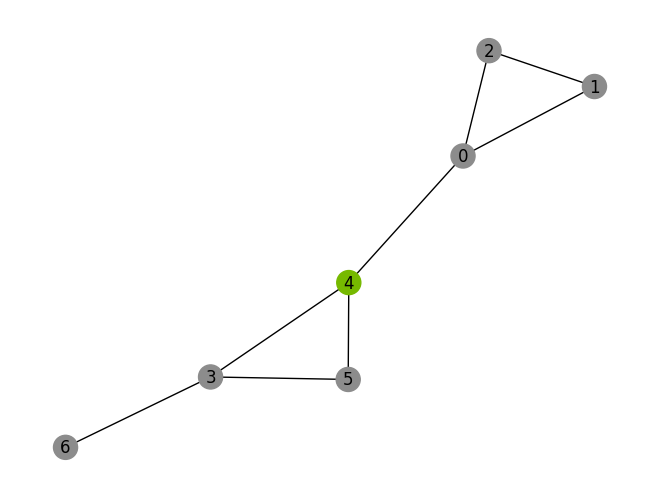

In [63]:
edgeList = [(0,1),(1,2),(2,0),(0,4),(4,5),(5,3),(4,3), (3,6)]
sampleGraph =nx.from_edgelist(edgeList)

nx.set_node_attributes(sampleGraph, values = 0, name = 'color')
sampleGraph.nodes[4]['color'] = 1

node_List : List[int] = list(sampleGraph.nodes())
edges_in_graph = list(sampleGraph.edges())
print('The graph has',sampleGraph.number_of_nodes(),'nodes and', sampleGraph.number_of_edges(), 'edges.')

gray ='#8C8C8C'
green ='#76B900'
color_map = [gray if sampleGraph.nodes[u]['color']==0 else green for u in sampleGraph]

pos = nx.spring_layout(sampleGraph, seed=311)
nx.draw(sampleGraph, with_labels=True, pos = pos, node_color=color_map)
plt.show()

Notice that the coloring above induces a cut with edges $(3,4)$, $(4,5)$, and $(0,4)$. This is not a maximum cut of this graph. The aim of this tutorial is to use a quantum algorithm to find a maximum cut.

In [64]:
sampleGraph.nodes[4]['color'] = 0

---

## 1.3 Classical approaches to Max Cut

Max Cut is [NP-hard](https://en.wikipedia.org/wiki/NP-hardness), meaning there is no known algorithm that solves it exactly in polynomial time for all graphs. As graphs grow, exact methods quickly become impractical:

- **Brute force** checks every possible split. For a graph with $n$ nodes this means $2^n$ possible assignments — feasible for our 7-node example, but utterly impractical for even moderately sized graphs.
- **Greedy and local-search heuristics** are fast but offer no guarantee on solution quality.
- **Semidefinite programming (SDP) relaxation** — the celebrated [Goemans-Williamson algorithm](https://math.mit.edu/~goemans/PAPERS/maxcut-jacm.pdf) (1995) guarantees a cut whose value is at least **0.878** times the optimal, using a beautiful randomized rounding of an SDP relaxation. This remains the best known worst-case approximation ratio for Max Cut.

Since our `sampleGraph` is small, we can find the exact answer by brute force to use as a benchmark for the quantum algorithm later.

In [65]:
# Brute-force: check every possible split (only practical for small graphs)
max_cut_value = 0
max_cut_edges = []
subsets = [[]]
for u in sampleGraph.nodes():
    subsets = subsets + [s + [u] for s in subsets]

for subset in subsets:
    cut_val = sum(1 for u, v in sampleGraph.edges()
                  if (u in subset) != (v in subset))
    if cut_val > max_cut_value:
        max_cut_value = cut_val
        group0 = subset

group1 = [u for u in sampleGraph.nodes() if u not in group0]

print(f"Exact max cut value: {max_cut_value}")
print(f"Groups: Group 0={group0}, Group 1={group1}")
print(f"\nWe'll use this as a benchmark for the QAOA result.")

Exact max cut value: 6
Groups: Group 0=[0, 3], Group 1=[1, 2, 4, 5, 6]

We'll use this as a benchmark for the QAOA result.


---

## 1.4 A Quantum Approach to Max Cut

We've seen that Max Cut is NP-hard — exact classical solutions don't scale. Quantum computing offers a fundamentally different approach. Before diving into the quantum algorithm, let's build up the key ideas using a simple triangle graph as a running example.

### 1.4.1 Qubits, Amplitudes, and Quantum Circuits

Classical computers store information in **bits** — each bit is either **0** or **1**. A quantum computer uses **qubits** instead. A qubit can be 0, can be 1, or — thanks to a quantum mechanical property called **superposition** — can exist in a blend of both simultaneously.

What does this have to do with Max Cut? Recall that a partition assigns each vertex to one of two groups (Group 0 or Group 1). If we assign one qubit per vertex, then:
- qubit = **0** means "this vertex is in Group 0"
- qubit = **1** means "this vertex is in Group 1"

A single state of all the qubits represents one specific partition. For example, with 3 vertices, the state `010` means: vertex 0 → Group 0, vertex 1 → Group 1, vertex 2 → Group 0.

One important difference between classical and quantum computing is **measurement**. A classical program can inspect any of its bits at any time without changing them. In a quantum computer, the state of the qubits is described by *amplitudes* — one for each possible outcome. An amplitude is a number whose squared magnitude gives the probability of seeing that outcome when we measure. This rule — probability equals amplitude squared — is called **Born's rule**. Measurement collapses the superposition: we get just *one* definite outcome, and the rest of the information is lost.

Here's the key insight: a system of $n$ qubits in superposition holds an amplitude for **every** one of the $2^n$ possible partitions. Our 7-node `sampleGraph` has $2^7 = 128$ possible partitions, so 7 qubits carry amplitudes for all 128 at once. To manipulate those amplitudes, a quantum computer applies **quantum gates** — basic operations that rotate or entangle qubits, much like logic gates (AND, OR, NOT) in a classical computer. A sequence of quantum gates is called a **quantum circuit**. A well-designed circuit exploits quantum interference: by carefully choosing the gates, we can make the amplitudes for good partitions grow and the amplitudes for bad partitions shrink, so that a good partition is what we're most likely to see when we measure

The widget below lets you see Born's rule and measurement in action on a single qubit. (The 3-D sphere in the widget is called the **Bloch sphere** — a standard way to visualize a single qubit's state, but you don't need to understand it to follow along.)

<div style="background-color: #f9fff0; border-left: 6px solid #76b900; padding: 15px 15px 15px 20px; border-radius: 4px; margin: 15px 0; color: #333;">

**<span style="color: #76b900; font-size: 1.17em;">Exercise 1:</span>**

<div style="display: flex; align-items: flex-start; gap: 20px;">
<div style="flex: 1;">

1. Drag the **θ** slider away from 0. Watch how the amplitudes (α and β) change and how the probability bars update according to Born's rule.
2. Click **"1 Shot"** a few times — each click is one measurement, collapsing the state to 0 or 1.
3. Try **"100 Shots"** to see the statistics converge to the predicted probabilities.

</div>
<div style="text-align: center; flex: 0 0 210px;">
<a href="https://nvidia.github.io/cuda-q-academic/quick-start-to-quantum/interactive_widget/borns-rule-widget-sampling.html" target="_blank">Open widget in a new tab</a>
</div>
</div>

</div>

In [66]:
# Born's Rule Interactive Widget
scale = 0.8
content_height = 1050
visible_height = int(content_height * scale)

HTML(f'''<div style="overflow:hidden; height:{visible_height}px;">
  <iframe src="https://nvidia.github.io/cuda-q-academic/quick-start-to-quantum/interactive_widget/borns-rule-widget-sampling.html"
    style="width:{int(100/scale)}%; height:{content_height}px; border:none;
           transform:scale({scale}); transform-origin:top left;">
  </iframe>
</div>''')

### 1.4.2 Seeing a quantum algorithm in action

Before diving into the math, let's see a quantum algorithm working on the simplest interesting graph: a **triangle** (3 nodes, 3 edges). Each node gets one qubit, so there are $2^3 = 8$ possible colorings. (The algorithm is called **QAOA** — Quantum Approximate Optimization Algorithm — and we'll explain exactly how it works in Section 1.5.)

The interactive app below lets you play the role of the optimizer. Two sliders control the algorithm's behavior:
- **Cost angle (α)** — encodes the graph structure
- **Mixer angle (β)** — controls interference between different colorings

<div style="background-color: #f9fff0; border-left: 6px solid #76b900; padding: 15px 15px 15px 20px; border-radius: 4px; margin: 15px 0; color: #333;">

**<span style="color: #76b900; font-size: 1.17em;">Exercise 2:</span>**

<div style="display: flex; align-items: flex-start; gap: 20px;">
<div style="flex: 1;">

1. **Start at α = 0, β = 0.** All 8 colorings are equally likely (12.5% each) — the qubits are in a uniform superposition. This is pure random guessing.
2. **Drag the sliders.** Watch the histogram shift — the balance between blue bars (good cuts that cut 2 edges) and gray bars (bad cuts that cut 0 edges) changes with each setting. For some parameter values the good cuts dominate; for others they don't. This redistribution is **quantum interference** at work.
3. **Press "Sample (Measure)."** The superposition collapses to one definite coloring — just as it would on a real quantum computer.
4. **Hover over any bar** to preview that coloring on the triangle.

Don't worry about the **⟨H⟩** badge yet — we'll explain exactly what it means in the next section.

</div>
<div style="text-align: center; flex: 0 0 210px;">
<a href="https://nvidia.github.io/cuda-q-academic/interactive_widgets/triangle-qaoa.html" target="_blank">Open widget in a new tab</a>
</div>
</div>

</div>

In [67]:
# QAOA Max Cut Explorer applet
scale = 0.8  # Change this to zoom: 0.7 = more zoomed out, 1.0 = full size
content_height = 1250  # Full height of the widget content in px
visible_height = int(content_height * scale)

HTML(f'''<div style="overflow:hidden; height:{visible_height}px;">
  <iframe src="https://nvidia.github.io/cuda-q-academic/interactive_widgets/triangle-qaoa.html"
    style="width:{int(100/scale)}%; height:{content_height}px; border:none;
           transform:scale({scale}); transform-origin:top left;">
  </iframe>
</div>''')

### 1.4.3 The Max Cut Hamiltonian — what's happening under the hood

You just watched probabilities shift as you tuned α and β. But what is the quantum circuit actually optimizing? To understand, we need to translate the graph into the language of quantum mechanics. The result is called a **Hamiltonian** — a scoring function that the quantum computer evaluates directly on its qubits.

For Max Cut, the Hamiltonian is:

$$H = \frac{1}{2}\sum_{(u,v)\in E} (Z_u Z_v - I)$$

Let's unpack this using the triangle you just explored.

#### What is $Z$?

$Z$ (the Pauli-Z operator) checks a qubit's value:
- If the qubit is in state **0**, $Z$ returns **+1**
- If the qubit is in state **1**, $Z$ returns **−1**

That's it — $Z$ converts our 0/1 partition labels into +1/−1 values.

#### What does $Z_u Z_v$ tell us?

For an edge $(u, v)$, the product $Z_u Z_v$ reveals whether the two endpoints are in the **same** group or **different** groups:

| Vertex $u$ | Vertex $v$ | $Z_u$ | $Z_v$ | $Z_u Z_v$ | Same group? | Edge cut? |
|:-:|:-:|:-:|:-:|:-:|:-:|:-:|
| 0 | 0 | +1 | +1 | **+1** | Yes | No |
| 0 | 1 | +1 | −1 | **−1** | No | **Yes** |
| 1 | 0 | −1 | +1 | **−1** | No | **Yes** |
| 1 | 1 | −1 | −1 | **+1** | Yes | No |

When the edge **is** cut: $\;\frac{1}{2}(Z_u Z_v - 1) = \frac{1}{2}(-1 - 1) = -1$

When the edge **is not** cut: $\;\frac{1}{2}(Z_u Z_v - 1) = \frac{1}{2}(+1 - 1) = 0$

So each cut edge contributes $-1$ to $H$, each uncut edge contributes $0$. **Minimizing** $H$ is the same as **maximizing** cut edges!

#### Worked example: hover over bitstring `100` in the QAOA Max Cut Explorer app

Go back to the QAOA Max Cut Explorer app and hover over the bar labeled **`100`**. You'll see node 0 turn green (Group 1) and nodes 1, 2 stay gray (Group 0). Two of the three edges are cut. Let's verify with the formula:

| Edge | $Z_u$ | $Z_v$ | $Z_u Z_v$ | $\frac{1}{2}(Z_u Z_v - 1)$ | Cut? |
|:-:|:-:|:-:|:-:|:-:|:-:|
| (0, 1) | −1 | +1 | −1 | −1 | ✓ |
| (1, 2) | +1 | +1 | +1 | 0 | ✗ |
| (0, 2) | −1 | +1 | −1 | −1 | ✓ |

$$H = (-1) + 0 + (-1) = -2$$

This partition cuts **2 out of 3** edges — the best you can do on a triangle. (Try hovering over `000` or `111` — those cut zero edges, giving $H = 0$.)

#### The expectation value ⟨H⟩ — what the green badge shows

Now look at the **⟨H⟩** badge in the QAOA Max Cut Explorer app. In quantum computing, we work with a superposition of *all* partitions simultaneously. The **expectation value** $\langle H \rangle$ is the weighted average of $H$ over all possible measurement outcomes:

$$\langle H \rangle = \sum_{i} P(\text{state } i) \times H(\text{state } i)$$

For the triangle, each of the 8 bitstrings has $H = 0$ (the two "all same color" states) or $H = -2$ (the six good-cut states). At α = β = 0, all 8 are equally likely (12.5% each):

$$\langle H \rangle = 2 \times 0.125 \times 0 + 6 \times 0.125 \times (-2) = -1.50$$

Go check — the badge should show exactly −1.50 at the default settings. As you find better parameters, ⟨H⟩ drops toward −2.00 — the quantum circuit is converging on a max cut.

<div style="background-color: #f9fff0; border-left: 6px solid #76b900; padding: 15px 15px 15px 20px; border-radius: 4px; margin: 15px 0; color: #333;">

**<span style="color: #76b900; font-size: 1.17em;">Exercise 3:</span>**

<div style="display: flex; align-items: flex-start; gap: 20px;">
<div style="flex: 1;">

Use the sliders in the QAOA Max Cut Explorer applet to push ⟨H⟩ all the way to −2.00. What combination of α and β achieves the optimum? How does the probability distribution change as you approach it?

</div>
<div style="text-align: center; flex: 0 0 210px;">
<a href="https://nvidia.github.io/cuda-q-academic/interactive_widgets/triangle-qaoa.html" target="_blank">Open widget in a new tab</a>
</div>
</div>

</div>

### 1.4.4 Key quantum concepts

The [QAOA Max Cut Explorer app](https://nvidia.github.io/cuda-q-academic/interactive_widgets/triangle-qaoa.html) illustrates the core quantum ideas that power the algorithm:

- **Superposition.** With α = β = 0, the quantum circuit puts all qubits into an equal superposition — every possible partition is equally likely. On a real quantum computer, superposition is what lets us represent all $2^n$ partitions at once.

- **Parameterized quantum circuit.** The α and β sliders control the circuit's behavior. Different parameter values produce different probability distributions over the 8 possible bitstrings. The circuit itself is fixed in structure; only the parameters change.

- **Quantum interference.** As you tune the parameters, the quantum amplitudes for different states add up constructively (boosting good partitions) or destructively (suppressing bad ones). This is fundamentally different from classical randomness — it's what gives quantum computing its potential advantage.

- **Expectation value.** The ⟨H⟩ badge shows the weighted average of the Hamiltonian over all possible measurement outcomes. It's the single number that the classical optimizer uses to judge how good the current parameters are. More negative = better. When ⟨H⟩ reaches its minimum (−2 for the triangle), the circuit has found parameter values where measurements are overwhelmingly likely to produce a max cut.

- **Measurement.** A quantum computer can't hand you the full probability distribution directly. When you press "Sample," the superposition collapses to a single bitstring — one specific partition. Better parameters mean a higher probability of measuring a good cut.

In practice, you don't tune the sliders by hand. A **classical optimizer** (a conventional algorithm on a regular computer) adjusts α and β automatically, trying to minimize ⟨H⟩. This **hybrid quantum-classical loop** is the essence of the algorithm — called **QAOA** — which we'll describe formally in Section 1.5.

---

## 1.5 QAOA: The Algorithm

Now that we have an intuition for what QAOA does, let's look at the algorithm more precisely.

**QAOA** is a **variational algorithm** — it uses a classical optimizer to tune the parameters of a quantum circuit until the circuit produces states that minimize the Hamiltonian (i.e., maximize the cut).

<img src="https://github.com/NVIDIA/cuda-q-academic/blob/main/qaoa-for-max-cut/images/QAOA-flowchart.png?raw=true" alt="Flowchart of the QAOA hybrid quantum-classical loop: input graph and Hamiltonian feed into an optimization loop where a quantum circuit is executed, the cost function is evaluated, and a classical optimizer updates parameters until convergence, then the final circuit is sampled to produce a Max Cut partition." />

The flowchart above illustrates the hybrid classical-quantum loop:
1. A classical optimizer proposes parameter values (the angles α and β you were adjusting manually in the widget).
2. A quantum circuit, parameterized by those values, prepares a quantum state.
3. The expectation value ⟨H⟩ is estimated — this is the same quantity you watched change in the widget (the `observe` step).
4. The classical optimizer uses ⟨H⟩ as feedback to propose new, better parameters, driving it more negative.
5. Once converged, the final circuit is sampled (the `sample` step) to read out a candidate solution.

### 1.5.1 Inside the QAOA circuit

The diagram below shows the general structure of a QAOA circuit — notice the similarity to what you saw in the triangle widget:

* For each vertex in the graph, there is one qubit in the circuit.
* **Hadamard gates (H)** on the left initialize every qubit into superposition, just like setting α = β = 0 in the widget. (A note on notation: the letter *H* is used for both the Hadamard gate and the Hamiltonian. This is an unfortunate collision that is standard in the field. Context makes it clear which is meant: *H* as a gate appears in circuit diagrams, while *H* as the Hamiltonian appears in cost expressions like $\langle H \rangle$.)
* The circuit then applies repeated *layers* of a **problem kernel** and a **mixer kernel**.
    * The **problem kernel** (blue) encodes the Hamiltonian — each edge in the graph produces quantum gates. This is the part of the computation dependent on the α parameter.
    * The **mixer kernel** (green) applies rotation gates that create quantum interference. This is the part of the computation dependent on the β parameter.

<img src="https://github.com/NVIDIA/cuda-q-academic/blob/main/qaoa-for-max-cut/images/qaoa-circuit-layers.png?raw=true" alt="Diagram of a QAOA circuit: Hadamard gates initialize all qubits into superposition, followed by repeated layers of a problem kernel (blue, encoding the graph Hamiltonian) and a mixer kernel (green, applying Rx rotations)." />

Looking more closely at the problem kernel: for each edge $(u,v)$ in the graph, a controlled-$X$ gate is applied between the corresponding qubits, followed by a parameterized $Z$-rotation and another controlled-$X$ gate.

<img src="https://github.com/NVIDIA/cuda-q-academic/blob/main/qaoa-for-max-cut/images/qaoa-problem-kernel.png?raw=true" alt="Detail of the QAOA problem kernel for a 5-node graph: for each edge, a CNOT gate connects the two qubits, a parameterized Rz rotation is applied, and a second CNOT completes the entangling operation. The edge (1,2) is highlighted." />

More QAOA layers (higher $p$) give the optimizer more knobs to turn, potentially finding better solutions — but at the cost of deeper circuits and more parameters to optimize.

---

## 1.6 Implementing QAOA with CUDA-Q

With CUDA-Q, you have the option to build every piece by hand — constructing the Hamiltonian, writing the parameterized quantum circuit (kernel) gate by gate, and coding the optimization loop yourself. This gives you full control and is a great way to deepen your understanding of the algorithm. If you'd like to explore that approach, check out the [QAOA for Max Cut notebook on CUDA-Q Academic](https://nvidia.github.io/cuda-q-academic/learningpath.html?custom=eyJ0aXRsZSI6IlFBT0EgZm9yIE1heCBDdXQiLCJkZXNjIjoiUUFPQSBmb3IgTWF4IEN1dCB3aXRoIENVREEtUSIsIm5icyI6W3sibmFtZSI6Ik1heCBDdXQgZm9yIFFBT0EiLCJjb2xhYiI6Imh0dHBzOi8vY29sYWIucmVzZWFyY2guZ29vZ2xlLmNvbS9naXRodWIvTlZJRElBL2N1ZGEtcS1hY2FkZW1pYy9ibG9iL21haW4vcWFvYS1mb3ItbWF4LWN1dC8wMV9NYXgtQ3V0LXdpdGgtUUFPQS5pcHluYiIsImdoIjoiaHR0cHM6Ly9naXRodWIuY29tL05WSURJQS9jdWRhLXEtYWNhZGVtaWMvYmxvYi9tYWluL3Fhb2EtZm9yLW1heC1jdXQvMDFfTWF4LUN1dC13aXRoLVFBT0EuaXB5bmIiLCJ0eXBlIjoibm90ZWJvb2sifV19).

However, since QAOA is such a standard workflow, the `cudaq_solvers` library wraps it all into a single function call. This lets us focus on the graph problem and the results — especially useful as we scale up and introduce techniques like circuit cutting later.

### 1.6.1 The Max Cut Hamiltonian in code

Using `cudaq_solvers`, we can generate the cost Hamiltonian directly from our NetworkX graph. Under the hood, this translates the graph's edges into the Pauli-Z operators we discussed in Section 1.4.2.

In [68]:
H = solvers.get_maxcut_hamiltonian(sampleGraph)

print("Max Cut Hamiltonian for sampleGraph:")
print(H)

Max Cut Hamiltonian for sampleGraph:
(-4+0i) + (0.5+0i) * Z3Z4 + (0.5+0i) * Z3Z5 + (0.5+0i) * Z3Z6 + (0.5+0i) * Z4Z5 + (0.5+0i) * Z1Z2 + (0.5+0i) * Z0Z1 + (0.5+0i) * Z0Z2 + (0.5+0i) * Z0Z4


### 1.6.2 Running the QAOA Solver

To find the optimal cut, we don't need to manually build the circuit layers or the quantum-classical loop. The `solvers.qaoa` command does the work for us. We just need to define:
1. The number of QAOA layers (p).
2. The initial parameters for the optimizer.
3. The optimizer type (e.g., COBYLA).

Let's wrap this into a reusable function so we can easily apply it to different subgraphs later.

In [69]:
def qaoa_for_graph(G, layer_count, seed):
    """Run QAOA to approximate the max cut of a graph using cudaq_solvers.

    Parameters
    ----------
    G: networkX graph
        Problem graph whose max cut we aim to approximate
    layer_count : int
        Number of layers in the QAOA circuit
    seed : int
        Random seed for reproducibility of results

    Returns
    -------
    str
        Binary string representing the most probable coloring found by QAOA
    """
    mapping = {node: i for i, node in enumerate(sorted(G.nodes()))}
    G_mapped = nx.relabel_nodes(G, mapping)

    H = solvers.get_maxcut_hamiltonian(G_mapped)

    parameter_count = 2 * layer_count
    np.random.seed(seed)
    cudaq.set_random_seed(seed)

    initial_parameters = np.random.uniform(-np.pi, np.pi, parameter_count)

    opt_value, opt_params, opt_config = solvers.qaoa(
        H,
        layer_count,
        initial_parameters,
        optimizer="cobyla"
    )

    print("Optimal parameters = ", opt_params)
    print("Most probable outcome = ", opt_config.most_probable())

    return str(opt_config.most_probable())

Let's run QAOA with a single layer (`p=1`) on `sampleGraph` and see what cut it finds. With only one layer, QAOA is a coarse approximation — depending on the random starting parameters, it may or may not land on the optimal cut.

The `seed` parameter controls both the classical optimizer's random starting point and the simulator's internal random number generator, making results fully reproducible. Execute the cell below to run the solver, interpret the resulting bitstring as a node coloring, and compute the cut value.

In [70]:
# Run this notebook on CPU by default using 'qpp-cpu'; use only explicitly marked QPU sections on real hardware.
# Since this quantum circuit is not too large, we can run it on a CPU.  For a full list of available targets, see:
# https://nvidia.github.io/cuda-quantum/latest/using/backends/backends.html
cudaq.set_target('qpp-cpu')

result = qaoa_for_graph(sampleGraph, layer_count=1, seed=110)

graphColors = [int(i) for i in result]
nodes = sorted(list(nx.nodes(sampleGraph)))

qaoa_cut_value = 0
cut_edges = []

for u, v in sampleGraph.edges():
    indexu = nodes.index(u)
    indexv = nodes.index(v)
    if graphColors[indexu] != graphColors[indexv]:
        qaoa_cut_value += 1
        cut_edges.append((u, v))

group0 = []
group1 = []
for u in sampleGraph.nodes():
    indexu = nodes.index(u)
    if graphColors[indexu] == 0:
        group0.append(u)
        sampleGraph.nodes[u]['color'] = 0
    else:
        group1.append(u)
        sampleGraph.nodes[u]['color'] = 1

print(f'\nQAOA (p=1) cut value: {qaoa_cut_value}  (optimal = {max_cut_value})')
print(f'Groups: Group 0={group0}, Group 1={group1}')
if qaoa_cut_value == max_cut_value:
    print('QAOA found the optimal max cut!')
else:
    print(f'QAOA found a suboptimal cut. With p=1, this can happen — try increasing p for more reliable results.')

Optimal parameters =  [-2.4899541730789516, 2.0772866111688355]
Most probable outcome =  0000111

QAOA (p=1) cut value: 4  (optimal = 6)
Groups: Group 0=[0, 1, 2, 3], Group 1=[4, 5, 6]
QAOA found a suboptimal cut. With p=1, this can happen — try increasing p for more reliable results.


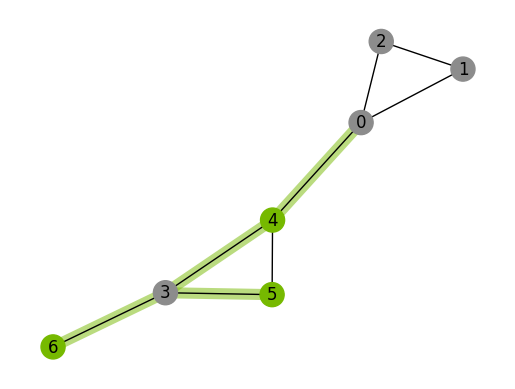

In [71]:
max_cut_color_map = [gray if sampleGraph.nodes[u]['color']==0 else green for u in sampleGraph]

nx.draw_networkx_edges(
    sampleGraph,
    pos,
    edgelist=cut_edges,
    width=8,
    alpha=0.5,
    edge_color=green,
)
nx.draw(sampleGraph, with_labels=True, pos = pos, node_color=max_cut_color_map)
plt.show()

**Did QAOA find the optimal cut?** Compare the cut value above to the brute-force optimum of 6 from Section 1.3. With `p=1`, QAOA sometimes finds the optimum and sometimes doesn't.

This isn't a bug — it's an important feature of variational quantum algorithms worth understanding. QAOA with a single layer has only **two parameters** (one α, one β), which limits how well it can steer probability toward the best bitstrings. Whether it succeeds depends on:

1. **Initial parameters** — different random starting points lead the classical optimizer to different local minima in the cost landscape.
2. **Landscape structure** — at `p=1` the landscape is shallow with many suboptimal basins (we'll visualize this in Section 1.7).
3. **Sampling** — even with good parameters, measurement is probabilistic; the most probable bitstring isn't guaranteed to be optimal.

Because a single QAOA layer can't reliably converge to the optimum, we need strategies that deliver **consistent, high-quality solutions** regardless of the randomness involved. This is exactly why deeper circuits (higher `p`), Adapt-QAOA (Section 1.9), and QAOA-GPT (Section 1.10) exist — each offers a different path to more reliable convergence.

An alternative method of coding QAOA is to define a kernel explicitly and run the optimization loop. Then using the optimal parameters found, use `cudaq.sample` to sample the circuit to identify a cut likely to approximate the max cut.

In [72]:
@cudaq.kernel
def kernel_qaoa_p1(qubits_num: int,
                    ham_word: list[cudaq.pauli_word],
                    ham_coef: list[complex],
                    thetas: list[float],
                    num_layers: int):
    qubits = cudaq.qvector(qubits_num)
    h(qubits)
    for p in range(num_layers):
        for i in range(len(ham_coef)):
            exp_pauli(thetas[2 * p] * ham_coef[i].real, qubits, ham_word[i])
        for j in range(qubits_num):
            rx(2.0 * thetas[2 * p + 1], qubits[j])

# Hamiltonian terms in Pauli word format
ham_word_hw = ['ZZIIIII', 'IIIIIII', 'IIIIIII', 'ZIZIIII', 'IIIIIII',
               'ZIIIZII', 'IIIIIII', 'IZZIIII', 'IIIIIII', 'IIIIZZI',
               'IIIIIII', 'IIIZZII', 'IIIIIII', 'IIIZIZI', 'IIIIIII',
               'IIIZIIZ', 'IIIIIII']
ham_coef_hw = [(0.5+0j), (-0.5-0j), 0j, (0.5+0j), (-0.5-0j),
               (0.5+0j), (-0.5-0j), (0.5+0j), (-0.5-0j), (0.5+0j),
               (-0.5-0j), (0.5+0j), (-0.5-0j), (0.5+0j), (-0.5-0j),
               (0.5+0j), (-0.5-0j)]

n_q = sampleGraph.number_of_nodes()
edges_in_graph = list(sampleGraph.edges())
node_idx_hw = {n: i for i, n in enumerate(sorted(sampleGraph.nodes()))}

# Re-extract the optimized p=1 parameters (same optimization as above)
mapping_hw = {node: i for i, node in enumerate(sorted(sampleGraph.nodes()))}
G_mapped_hw = nx.relabel_nodes(sampleGraph, mapping_hw)
H_hw = solvers.get_maxcut_hamiltonian(G_mapped_hw)

np.random.seed(110)
cudaq.set_random_seed(110)
init_params_hw = np.random.uniform(-np.pi, np.pi, 2)
_, opt_params_p1, _ = solvers.qaoa(H_hw, 1, init_params_hw, optimizer="cobyla")

print(f"Optimized p=1 parameters: \u03b3 = {opt_params_p1[0]:.6f},  \u03b2 = {opt_params_p1[1]:.6f}")

Optimized p=1 parameters: γ = -2.489954,  β = 2.077287


In [73]:
shots = 5000

def cut_value_from_bitstring(bitstring):
    """Compute the cut value for a given bitstring coloring."""
    return sum(1 for u, v in edges_in_graph
               if bitstring[node_idx_hw[u]] != bitstring[node_idx_hw[v]])

# ══ Sample in simulation (reference) ════════════════════════════════════════
cudaq.set_target('qpp-cpu')
counts_sim = cudaq.sample(
    kernel_qaoa_p1, n_q, ham_word_hw, ham_coef_hw,
    list(opt_params_p1), 1, shots_count=shots
)

sim_bs = counts_sim.most_probable()
sim_cut = cut_value_from_bitstring(sim_bs)
print(f"Simulation  \u2014 most probable: {sim_bs}  (cut = {sim_cut} / {max_cut_value})")


Simulation  — most probable: 1011101  (cut = 4 / 6)


---

## 1.7 Challenges in scaling QAOA

QAOA works beautifully on small graphs like our 7-node example. But as we try to tackle larger, real-world problems, two distinct challenges emerge:

**Challenge 1 — Qubit count.** QAOA needs one qubit per vertex. A 100-node graph requires 100 qubits; a 1000-node graph requires 1000. Today's quantum processors have limited qubit counts, and classical GPU simulators face exponential memory scaling ($O(2^n)$ for the state vector). **Divide-and-conquer** approaches address this by breaking a large graph into smaller subgraphs that each fit on available hardware (Section 1.8).

**Challenge 2 — Circuit depth and barren plateaus.** The **circuit depth** is the number of sequential gate layers in a quantum circuit — it determines how long the qubits must stay coherent. Even if we have enough qubits, deeper circuits (more QAOA layers) can lead to **barren plateaus** — regions where the cost landscape becomes exponentially flat, making it nearly impossible for the classical optimizer to find a good direction. **Adapt-QAOA** (Section 1.9) and **QAOA-GPT** (Section 1.10) attack this problem from different angles.

Let's visualize the barren plateau problem first, then tackle each challenge in turn.

### 1.7.1 The QAOA optimization landscape

In Exercise 2, you manually tuned α and β to find good cuts on the triangle. The classical optimizer inside QAOA does the same thing — but it navigates a **cost landscape**: the expectation value of the Hamiltonian plotted as a function of the parameters. The widget below visualizes this landscape.

<div style="background-color: #f9fff0; border-left: 6px solid #76b900; padding: 15px 15px 15px 20px; border-radius: 4px; margin: 15px 0; color: #333;">

**<span style="color: #76b900; font-size: 1.17em;">Exercise 4:</span>**

<div style="display: flex; align-items: flex-start; gap: 20px;">
<div style="flex: 1;">

Explore the landscape, then use the **"Barren plateau"** slider to increase the problem size. What happens to the valleys and gradients? At what point does the landscape become too flat for an optimizer to find a good direction?

</div>
<div style="text-align: center; flex: 0 0 210px;">
<a href="https://nvidia.github.io/cuda-q-academic/interactive_widgets/qaoa-landscape.html" target="_blank">Open widget in a new tab</a>
</div>
</div>

</div>

**What to look for:**
- **Clear valleys** correspond to good parameter values — the optimizer can follow the gradient downhill.
- As the problem size increases, the landscape flattens: the valleys disappear, gradients vanish, and the optimizer has no signal to follow. This is the **barren plateau** problem — and it's why simply adding more QAOA layers doesn't always help.

We'll return to barren plateaus when we discuss Adapt-QAOA (Section 1.9) and QAOA-GPT (Section 1.10), which offer strategies for navigating or avoiding them entirely.

In [74]:
# QAOA Cost Landscape and Barren Plateau applet
scale = 0.8  # Change this to zoom: 0.7 = more zoomed out, 1.0 = full size
content_height = 1250  # Full height of the widget content in px
visible_height = int(content_height * scale)

HTML(f'''<div style="overflow:hidden; height:{visible_height}px;">
  <iframe src="https://nvidia.github.io/cuda-q-academic/interactive_widgets/qaoa-landscape.html"
    style="width:{int(100/scale)}%; height:{content_height}px; border:none;
           transform:scale({scale}); transform-origin:top left;">
  </iframe>
</div>''')

---

## 1.8 Addressing qubit scaling: divide-and-conquer QAOA

Let's tackle **Challenge 1** from Section 1.7: what do we do when the graph has more vertices than we have qubits (or than we can efficiently simulate)?

The idea is simple: **break the large graph into smaller subgraphs**, solve Max Cut on each subgraph independently with QAOA, then stitch the solutions back together. This is **divide-and-conquer QAOA**, and it has three stages:

### 1.8.1 Divide: Dividing the sampleGraph into two smaller subgraphs

Our `sampleGraph` is small and easy to visualize. A natural partition of the graph is to break the graph at the edge $(0,4)$, leaving us with two smaller disjoint subgraphs: `sampleSubgraph0` and `sampleSubgraph1` which we will draw below.

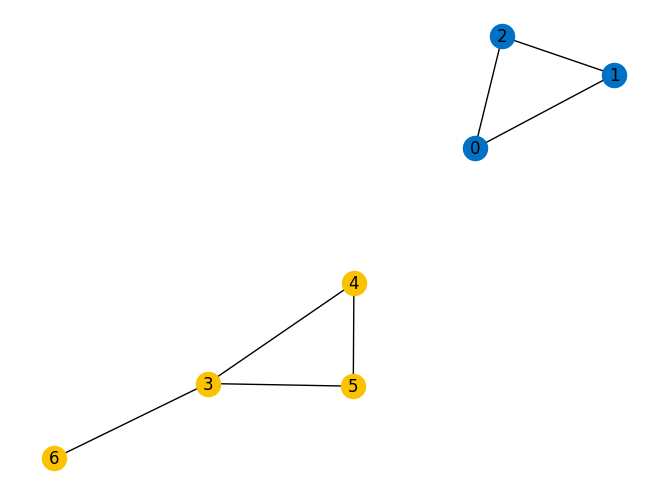

In [75]:
blue = '#0071C5'
yellow = '#FAC200'

subGraph_dictionary = {}
subgraphColors={}
subGraph_names=[]
for i in range(2):
    name='sampleSubgraph'+str(i)
    subGraph_names.append(name)
    if i ==0:
        subgraphColors[name] = blue
    else:
        subgraphColors[name] = yellow

nodes0 = [0,1,2]
subGraph_dictionary[subGraph_names[0]] = nx.subgraph(sampleGraph, nodes0)

nodes1 = [3,4,5,6]
subGraph_dictionary[subGraph_names[1]] = nx.subgraph(sampleGraph, nodes1)

for key in subGraph_dictionary:
    nx.draw(subGraph_dictionary[key], pos=pos, with_labels=True, node_color = subgraphColors[key])
plt.show()

### 1.8.2 Conquer: Solving the subgraph problems using QAOA

Breaking `sampleGraph` into two smaller graphs not only reduces the number of qubits required in each QAOA pass, but it also affords us the ability to compute the max cut of these subgraphs in parallel. We use `qaoa_for_graph` on each subgraph independently:

In [76]:
cudaq.set_target('qpp-cpu')

layer_count = 1

# Set random seed for reproducibility
seed = {}
i = 4
for key in subGraph_dictionary:
    seed[key] = i
    i += 13

results = {}

for key in subGraph_dictionary:
    print(f'\nRunning solver for {key}:')
    G = subGraph_dictionary[key]
    results[key] = qaoa_for_graph(G, layer_count, seed[key])


Running solver for sampleSubgraph0:
Optimal parameters =  [2.5260829154391766, 0.3077202545841778]
Most probable outcome =  100

Running solver for sampleSubgraph1:
Optimal parameters =  [-0.6528970661725311, 0.32934783619149754]
Most probable outcome =  0101


### 1.8.3 Merge: Determining a (perhaps non-optimal) cut of the sampleGraph from the subgraph solutions

Because no vertex lies in both subgraphs, we can use the subgraph solutions to generate a (possibly non-optimal) cut of the original `sampleGraph` by coloring each node with the colors determined by the subgraph solutions. We'll find a better cut in the next subsection.

The cut value for this partition is 5.
This is less than the optimal value of 6 that we found earlier.
We have not optimally combined the subgraph max cut solutions into a
solution for sampleGraph. We can be more careful about how we merge
together the subgraph solutions to generate a cut of the original graph.
We'll explore this in the next section.


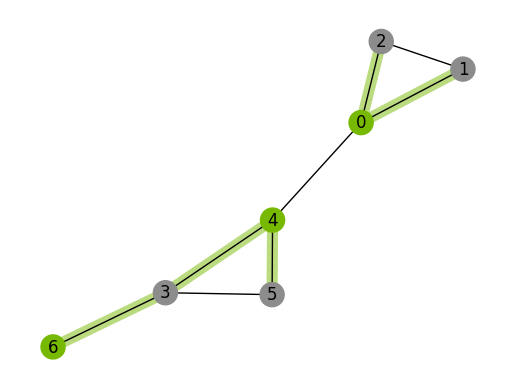

In [77]:
for key in subGraph_dictionary:
    graphColors=[int(i) for i in results[key]]
    nodes = sorted(list(nx.nodes(subGraph_dictionary[key])))

    for u in sampleGraph.nodes():
        if u in nodes:
            indexu = nodes.index(u)
            if graphColors[indexu] == 0:
                sampleGraph.nodes[u]['color']= 0
            else:
                sampleGraph.nodes[u]['color']= 1

cut_edges =[]
for u, v in sampleGraph.edges():
    if sampleGraph.nodes[u]['color']!= sampleGraph.nodes[v]['color']:
        cut_edges+=[(u,v)]

print(f'The cut value for this partition is {len(cut_edges)}.')
if len(cut_edges) < max_cut_value:
    print(f'This is less than the optimal value of {max_cut_value} that we found earlier.')
    print('We have not optimally combined the subgraph max cut solutions into a')
    print('solution for sampleGraph. We can be more careful about how we merge')
    print("together the subgraph solutions to generate a cut of the original graph.")
    print("We'll explore this in the next section.")
else:
    print(f'This matches the optimal value of {max_cut_value} — the naive merge already found an optimal cut!')

max_cut_color_map = [gray if sampleGraph.nodes[u]['color']==0 else green for u in sampleGraph]

nx.draw_networkx_edges(
    sampleGraph,
    pos,
    edgelist=cut_edges,
    width=8,
    alpha=0.5,
    edge_color=green,
)
nx.draw(sampleGraph, with_labels=True, pos = pos, node_color=max_cut_color_map)
plt.show()

### 1.8.4 Merge: Finding a better merger of the subgraph solutions

This step is entirely **classical post-processing** — no quantum hardware is involved. It highlights the *hybrid* nature of divide-and-conquer QAOA: the quantum solver finds good cuts within each subgraph, and then a classical algorithm stitches those partial solutions together as effectively as possible.

Instead of directly merging the subgraph solutions together as we did above, we can inspect the edges that do not lie in either subgraph and make some adjustments to the colorings before stitching them together.

In the example above, the edge $(0,4)$ is not included in the cut deduced from the merger of the subgraph solutions because both $0$ and $4$ were colored gray. Suppose we could change the coloring of `sampleSubgraph0` without reducing the cut value of the subgraph, but while also ensuring that $0$ gets colored green. Then, we would be able to include edge $(0,4)$ in the merged cut, resulting in a larger cut value for the `sampleGraph`.

Notice that the `sampleSubgraph0` cut value resulting from the node coloring `100` is the same as the one coded by `011`. By simply swapping the colors of the `sampleSubgraph0` result, we can find a better (optimal) cut for the `sampleGraph` because the cut value for `sampleSubgraph0` will remain the same, but we will capture the edge $(0,4)$ in our cut of the `sampleGraph` with this new coloring.

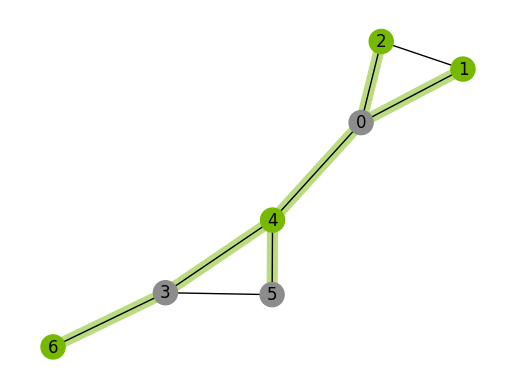

In [78]:
for key in subGraph_dictionary:
    if key == 'sampleSubgraph0':
        graphColors=[1-int(i) for i in results[key]]
    else:
        graphColors=[int(i) for i in results[key]]

    nodes = sorted(list(nx.nodes(subGraph_dictionary[key])))

    for u in sampleGraph.nodes():
        if u in nodes:
            indexu = nodes.index(u)
            if graphColors[indexu] == 0:
                sampleGraph.nodes[u]['color']= 0
            else:
                sampleGraph.nodes[u]['color']= 1

cut_edges =[]
for u, v in sampleGraph.edges():
    if sampleGraph.nodes[u]['color']!= sampleGraph.nodes[v]['color']:
        cut_edges+=[(u,v)]

max_cut_color_map = [gray if sampleGraph.nodes[u]['color']==0 else green for u in sampleGraph]

nx.draw_networkx_edges(
    sampleGraph,
    pos,
    edgelist=cut_edges,
    width=8,
    alpha=0.5,
    edge_color=green,
)
nx.draw(sampleGraph, with_labels=True, pos = pos, node_color=max_cut_color_map)

plt.show()

Hooray! We have found a max cut of the original graph using our subgraph solutions. It's a different solution from the one that we originally found, but it's just as good!

One subtlety we glossed over: we chose *how* to partition the graph by hand. In general, choosing a good partition — one that minimizes the number of edges cut between subgraphs and therefore reduces the classical post-processing overhead — is itself a hard combinatorial problem. For large graphs this choice matters a great deal, and AI-driven methods are beginning to address it. For example, *Adaptive Circuit Knitting* finds efficient partitions by locating regions of minimal entanglement between subsystems, reducing circuit knitting sampling overhead by up to four orders of magnitude. See: Johnson *et al.*, ["Distributed Quantum Computing via Adaptive Circuit Knitting"](https://arxiv.org/abs/2603.12411), *arXiv:2603.12411* (2026).

---

## 1.9 Addressing circuit depth: Adapt-QAOA

In Section 1.7, we saw how deeper QAOA circuits can run into **barren plateaus** — the cost landscape flattens and the optimizer loses its signal. One approach to this problem is to let the algorithm *build its own circuit* rather than using a fixed template.

Think of Adapt-QAOA like a **greedy algorithm** for building circuits: instead of using a pre-made template (the fixed layers of standard QAOA), we look at our current state and ask, *"Which single gate would help the most right now?"* Then, we add it, re-tune, and repeat.

In standard QAOA, the circuit structure is fixed. Before we run the program, we decide in advance how many layers to use, and each layer applies the same problem and mixer operators. The classical optimizer only tunes the *parameters*. **Adapt-QAOA** takes a different approach: it grows the circuit one operator at a time, always choosing the operator that improves the cost function the most:

<img src="https://github.com/NVIDIA/cuda-q-academic/blob/main/images/Adapt-QAOA-flowchart.png?raw=true" alt="Flowchart of Adapt-QAOA: evaluate candidate operators, choose the one with the largest gradient, optimize the circuit parameters, and repeat until convergence." />

The flowchart above shows the adaptive loop that incrementally builds the circuit based on which operator is most useful at each step.

1. Start with a **pool** of candidate operators (different mixer gates — think of this as a menu of possible next moves).
2. Compute the **gradient** of the cost function with respect to adding each operator (i.e., ask "how much would this gate help if I turned it on just a little?")
3. Select the operator with the **largest gradient** and append it to the circuit.
4. Re-optimize all parameters.
5. Repeat until the gradients are small enough (convergence).

But what does "largest gradient" actually mean? The widget below makes this concrete. Imagine you've just run one layer of QAOA and you want to add one more operator to improve the result. You have several candidates, and each one changes the cost differently depending on how strongly you apply it (a parameter θ). The **gradient** is just the slope of the cost curve at θ = 0 (e.g., how fast the cost changes when you first turn on that operator). A steep slope means big changes in the cost function (i.e., cut value); a flat slope means the operator barely has an effect.

<div style="background-color: #f9fff0; border-left: 6px solid #76b900; padding: 15px 15px 15px 20px; border-radius: 4px; margin: 15px 0; color: #333;">

**<span style="color: #76b900; font-size: 1.17em;">Exercise 5:</span>**

<div style="display: flex; align-items: flex-start; gap: 20px;">
<div style="flex: 1;">

One QAOA layer has already been applied to a triangle graph. Your job: decide which operator to add next.

1. Click each operator button and drag the **θ slider** away from 0 — watch the C(θ) curve change shape.
2. Check the **gradient readout**: which operator has the steepest downward slope at θ = 0?
3. That's your pick. Click **"Add operator"** to append it to the circuit.

</div>
<div style="text-align: center; flex: 0 0 210px;">
<a href="https://nvidia.github.io/cuda-q-academic/interactive_widgets/operator-gradient.html" target="_blank">Open widget in a new tab</a>
</div>
</div>

</div>



In [79]:
# Operator Gradient applet
scale = 0.8  # Change this to zoom: 0.7 = more zoomed out, 1.0 = full size
content_height = 1250  # Full height of the widget content in px
visible_height = int(content_height * scale)

HTML(f'''<div style="overflow:hidden; height:{visible_height}px;">
  <iframe src="https://nvidia.github.io/cuda-q-academic/interactive_widgets/operator-gradient.html"
    style="width:{int(100/scale)}%; height:{content_height}px; border:none;
           transform:scale({scale}); transform-origin:top left;">
  </iframe>
</div>''')

The key insight is that by *adapting* the circuit structure, Adapt-QAOA can often find better solutions with *fewer* total gates than a fixed-depth QAOA — or achieve the same quality with shallower circuits. This directly combats barren plateaus: instead of blindly stacking layers and hoping the optimizer can navigate a flat landscape, Adapt-QAOA only adds operations that demonstrably improve the solution.

We'll see concrete numbers on our 7-node sample graph in Section 1.11, but the takeaway is clear: by choosing *which* operators to apply rather than repeating the same fixed template, Adapt-QAOA can reach better solutions with the same (or fewer) total parameters. In Section 1.9.1 below, you'll try this yourself — picking one operator to add to the p=1 circuit and testing it on the IQM QPU.


The widget above showed how individual operator gradients guide the selection of the next gate. The interactive demo below puts the **full ADAPT-QAOA loop** in your hands for a slightly larger graph: you'll build the ansatz layer-by-layer — selecting the mixer with the largest gradient from a pool, optimizing parameters, and watching the cost converge — while a standard QAOA baseline runs side by side for comparison.

<div style="background-color: #f9fff0; border-left: 6px solid #76b900; padding: 15px 15px 15px 20px; border-radius: 4px; margin: 15px 0; color: #333;">

**<span style="color: #76b900; font-size: 1.17em;">Exercise 6:</span>**

<div style="display: flex; align-items: flex-start; gap: 20px;">
<div style="flex: 1;">

1. In the **ADAPT-QAOA** panel, click the mixer button with the largest gradient (green bar) to add it as the next layer.
2. Click **"Minimize (γ, β)"** to optimize the parameters for the circuit so far.
3. Repeat until the algorithm converges (gradient norm drops below threshold).
4. Click **"Run QAOA (p=4)"** to see how standard QAOA compares on the same 5-node Max-Cut instance.
5. Compare the two cost curves: how quickly does each approach reach the optimum?

</div>
<div style="text-align: center; flex: 0 0 210px;">
<a href="https://nvidia.github.io/cuda-q-academic/interactive_widgets/adapt-qaoa.html" target="_blank">Open widget in a new tab</a>
</div>
</div>

</div>

In [80]:
# ADAPT-QAOA vs. Standard QAOA applet
scale = 0.8  # Change this to zoom: 0.7 = more zoomed out, 1.0 = full size
content_height = 2350  # Full height of the widget content in px
visible_height = int(content_height * scale)

HTML(f'''<div style="overflow:hidden; height:{visible_height}px;">
  <iframe src="https://nvidia.github.io/cuda-q-academic/interactive_widgets/adapt-qaoa.html"
    style="width:{int(100/scale)}%; height:{content_height}px; border:none;
           transform:scale({scale}); transform-origin:top left;">
  </iframe>
</div>''')

**Further reading:**
- Zhu *et al.*, ["An adaptive quantum approximate optimization algorithm for solving combinatorial problems on a quantum computer"](https://journals.aps.org/prresearch/abstract/10.1103/PhysRevResearch.4.033029), *Phys. Rev. Research* **4**, 033029 (2022)
- [ADAPT-QAOA algorithm — CUDA-Q documentation](https://nvidia.github.io/cuda-quantum/latest/applications/python/adapt_qaoa.html)

### 1.9.1 Extending the p=1 circuit — your first step toward Adapt-QAOA

The widget above illustrated the core idea on a 5-vertex graph: different operators have different gradients, and the steepest one improves the cost fastest. Now let's apply exactly this strategy to our 7-node `sampleGraph` with CUDA-Q simulations — and then test the result on **IQM quantum hardware**.

<div style="background-color: #f9fff0; border-left: 6px solid #76b900; padding: 15px 15px 15px 20px; border-radius: 4px; margin: 15px 0; color: #333;">

**<span style="color: #76b900; font-size: 1.17em;">Exercise 7:</span>**

1. Start from the optimized QAOA p=1 circuit (the parameters we found in Section 1.6).
2. Evaluate a pool of candidate operators by computing each one's **gradient** — how steeply the cost drops when you first turn it on (θ = 0 → small θ).
3. Pick the winner and optimize its strength parameter θ.
4. Run the improved circuit on the **IQM QPU** and compare to the plain p=1 baseline.

</div>

This is precisely one iteration of the Adapt-QAOA loop done by hand. We start by defining a QAOA kernel that applies the fixed p=1 layer (using the parameters we already optimized in Section 1.6) followed by one extra operator of your choice.

In [81]:
@cudaq.kernel
def kernel_p1_plus_operator(qubits_num: int,
                             ham_word: list[cudaq.pauli_word],
                             ham_coef: list[complex],
                             base_params: list[float],
                             extra_op: list[cudaq.pauli_word],
                             extra_theta: float):
    qubits = cudaq.qvector(qubits_num)
    h(qubits)
    # Fixed QAOA layer 1 (same as kernel_qaoa_p1 with the optimized params)
    for i in range(len(ham_coef)):
        exp_pauli(base_params[0] * ham_coef[i].real, qubits, ham_word[i])
    for j in range(qubits_num):
        rx(2.0 * base_params[1], qubits[j])
    # One additional operator — this is what you're choosing
    exp_pauli(extra_theta, qubits, extra_op[0])

We define a pool of candidate operators — a mix of single-qubit rotations and two-qubit entangling gates acting on various edges of the graph. For each candidate, we compute the **gradient** at θ = 0 using finite differences:

$$\text{gradient} \approx \frac{E(\varepsilon) - E(-\varepsilon)}{2\varepsilon}$$

This works for any operator — single Pauli strings, sums of Paulis, or any other generator you can express with `exp_pauli`. (For single Pauli generators there is also an exact method called the [parameter shift rule](https://nvidia.github.io/cuda-quantum/latest/applications/python/vqe_advanced.html), but finite differences are more general and simpler to apply across a mixed operator pool.)

A large negative gradient means the cost drops steeply when the operator is first turned on — exactly what we saw on the C(θ) plot in the widget. The operator with the steepest slope is the one Adapt-QAOA would select.

> **Optional extension:** Try adding your own operators to the pool! Any 7-character Pauli string (using `I`, `X`, `Y`, `Z`) defines a valid operator on the 7-qubit system.

In [82]:
cudaq.set_target('qpp-cpu')

candidate_operators = [
    ('XIIIIII', 'X₀  (single-qubit)'),
    ('IIIXIII', 'X₃  (single-qubit)'),
    ('IIIIIIX', 'X₆  (single-qubit)'),
    ('YYIIIII', 'Y₀Y₁  (edge 0–1)'),
    ('IIIYYII', 'Y₃Y₄  (edge 3–4)'),
    ('IIIIYYI', 'Y₄Y₅  (edge 4–5)'),
    ('IIIZIIY', 'Z₃Y₆  (edge 3–6)'),
    # YOUR OPERATORS HERE — try adding more candidates!
]

eps = 0.005
base_params = list(opt_params_p1)

base_cost = cudaq.observe(
    kernel_p1_plus_operator, H_hw, n_q,
    ham_word_hw, ham_coef_hw, base_params, ['IIIIIII'], 0.0
).expectation()

print(f"QAOA p=1 baseline cost: {base_cost:.4f}  (optimal = -{max_cut_value})")
print(f"\n{'Operator':<28} {'Gradient':>10}  {'|Gradient|':>10}")
print('=' * 52)

gradient_results = []
for pauli_str, label in candidate_operators:
    E_plus = cudaq.observe(
        kernel_p1_plus_operator, H_hw, n_q,
        ham_word_hw, ham_coef_hw, base_params, [pauli_str], eps
    ).expectation()

    E_minus = cudaq.observe(
        kernel_p1_plus_operator, H_hw, n_q,
        ham_word_hw, ham_coef_hw, base_params, [pauli_str], -eps
    ).expectation()

    grad = (E_plus - E_minus) / (2 * eps)
    gradient_results.append((pauli_str, label, grad))
    print(f"  {label:<26} {grad:>+10.4f}  {abs(grad):>10.4f}")

best_op_str, best_op_label, best_grad = max(gradient_results, key=lambda x: abs(x[2]))
print(f"\n→ Steepest gradient: {best_op_label}  (gradient = {best_grad:+.4f})")

QAOA p=1 baseline cost: -3.9436  (optimal = -6)

Operator                       Gradient  |Gradient|
  X₀  (single-qubit)            -0.4778      0.4778
  X₃  (single-qubit)            +0.0701      0.0701
  X₆  (single-qubit)            +0.1060      0.1060
  Y₀Y₁  (edge 0–1)              +0.1260      0.1260
  Y₃Y₄  (edge 3–4)              -1.1487      1.1487
  Y₄Y₅  (edge 4–5)              -0.0017      0.0017
  Z₃Y₆  (edge 3–6)              -0.7951      0.7951

→ Steepest gradient: Y₃Y₄  (edge 3–4)  (gradient = -1.1487)


> **Questions:**
> - Which operator has the steepest gradient? Is it a single-qubit or two-qubit operator?
> - Why might two-qubit operators be more effective here, given that the standard QAOA mixer already applies single-qubit X rotations on every qubit?
> - Does the winning operator correspond to an edge in the graph? What does that tell you about which parts of the graph the p=1 circuit struggled with?

Now let's optimize the strength θ of the best operator by scanning across a range of values. We'll plot C(θ) — the same curve you explored in the widget — and find the θ that minimizes the cost.

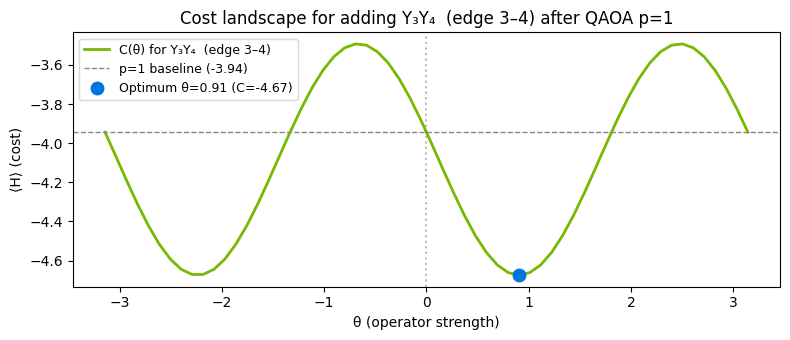

Optimized θ = 0.9052
Cost: -3.9436 → -4.6743  (ΔC = -0.7307)
Most probable bitstring: 0111101  (cut = 5 / 6)


In [83]:
thetas_scan = np.linspace(-np.pi, np.pi, 60)
costs_scan = []
for t in thetas_scan:
    e = cudaq.observe(
        kernel_p1_plus_operator, H_hw, n_q,
        ham_word_hw, ham_coef_hw, base_params, [best_op_str], t
    ).expectation()
    costs_scan.append(e)

opt_idx = np.argmin(costs_scan)
opt_extra_theta = thetas_scan[opt_idx]
opt_cost = costs_scan[opt_idx]

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(thetas_scan, costs_scan, color='#76b900', linewidth=2,
        label=f'C(θ) for {best_op_label}')
ax.axhline(base_cost, color='#888', linestyle='--', linewidth=1,
           label=f'p=1 baseline ({base_cost:.2f})')
ax.axvline(0, color='#555', linestyle=':', alpha=0.4)
ax.plot(opt_extra_theta, opt_cost, 'o', color='#0074df', markersize=9,
        zorder=5, label=f'Optimum θ={opt_extra_theta:.2f} (C={opt_cost:.2f})')
ax.set_xlabel('θ (operator strength)')
ax.set_ylabel('⟨H⟩ (cost)')
ax.set_title(f'Cost landscape for adding {best_op_label} after QAOA p=1')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

counts_extended_sim = cudaq.sample(
    kernel_p1_plus_operator, n_q,
    ham_word_hw, ham_coef_hw, base_params, [best_op_str], opt_extra_theta,
    shots_count=5000
)

ext_bs = counts_extended_sim.most_probable()
ext_cut = cut_value_from_bitstring(ext_bs)

print(f"Optimized θ = {opt_extra_theta:.4f}")
print(f"Cost: {base_cost:.4f} → {opt_cost:.4f}  (ΔC = {opt_cost - base_cost:+.4f})")
print(f"Most probable bitstring: {ext_bs}  (cut = {ext_cut} / {max_cut_value})")

### 1.9.2 Test your improved circuit on the QPU

You've found the best operator to add and optimized its parameter — all in simulation. Now send the improved circuit to **IQM Garnet** and see if real quantum hardware confirms the improvement.

<div style="background-color: #f9fff0; border-left: 6px solid #76b900; padding: 15px 15px 15px 20px; border-radius: 4px; margin: 15px 0; color: #333;">

**<span style="color: #76b900; font-size: 1.17em;">Exercise 7 (continued):</span>**

Uncomment the QPU section below and run it. Compare three results side by side:
- **QAOA p=1** — the baseline from Section 1.6.3
- **p=1 + your operator** (simulation) — the result you just computed
- **p=1 + your operator** (QPU) — same circuit on real hardware

**Think about:**
- Does the extra operator improve the cut value on real hardware, or does noise wash out the benefit?
- How does the QPU distribution differ from the simulator? What might cause these differences?
- What would happen if you repeated this process — picking and adding another operator? That's the full Adapt-QAOA loop!

</div>

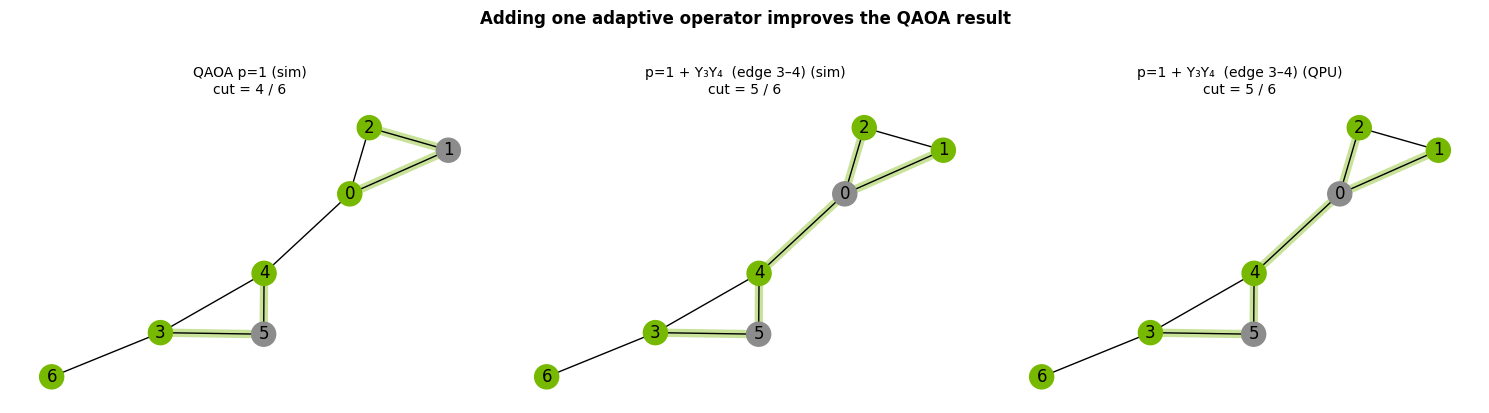


Summary:
  QAOA p=1 baseline:       cut = 4 / 6  (cost = -3.94)
  p=1 + Y₃Y₄  (edge 3–4):  cut = 5 / 6  (cost = -4.67)
  Adapt-QAOA (4 layers):   cut = 6 / 6  (cost = -6.00, pre-computed)


In [84]:
# ══ QPU execution (uncomment when you have an IQM token) ═════════════════
# cudaq.set_target('iqm', url=iqm_url)
# counts_ext_qpu = cudaq.sample(
#     kernel_p1_plus_operator, n_q,
#     ham_word_hw, ham_coef_hw, base_params, [best_op_str], opt_extra_theta,
#     shots_count=5000
# )
# ext_qpu_bs = counts_ext_qpu.most_probable()[::-1]  # IQM qubit ordering
# ext_qpu_cut = cut_value_from_bitstring(ext_qpu_bs)
# print(f"Extended circuit (QPU): {ext_qpu_bs}  (cut = {ext_qpu_cut} / {max_cut_value})")

# ══ Side-by-side comparison ══════════════════════════════════════════════
cudaq.set_target('qpp-cpu')

counts_p1_ref = cudaq.sample(
    kernel_qaoa_p1, n_q, ham_word_hw, ham_coef_hw,
    list(opt_params_p1), 1, shots_count=5000
)
p1_ref_bs = counts_p1_ref.most_probable()
p1_ref_cut = cut_value_from_bitstring(p1_ref_bs)

ext_hw_bs = ext_bs  # ← replace with ext_qpu_bs when running on the QPU

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

titles = [
    f'QAOA p=1 (sim)\ncut = {p1_ref_cut} / {max_cut_value}',
    f'p=1 + {best_op_label} (sim)\ncut = {ext_cut} / {max_cut_value}',
    f'p=1 + {best_op_label} (QPU)\ncut = {cut_value_from_bitstring(ext_hw_bs)} / {max_cut_value}'
]
bitstrings = [p1_ref_bs, ext_bs, ext_hw_bs]

for ax, title, bs in zip(axes, titles, bitstrings):
    colors = [gray if int(bs[node_idx_hw[u]]) == 0 else green
              for u in sampleGraph]
    ce = [(u, v) for u, v in sampleGraph.edges()
          if bs[node_idx_hw[u]] != bs[node_idx_hw[v]]]
    nx.draw_networkx_edges(sampleGraph, pos, edgelist=ce,
                           width=6, alpha=0.4, edge_color=green, ax=ax)
    nx.draw(sampleGraph, with_labels=True, pos=pos,
            node_color=colors, ax=ax)
    ax.set_title(title, fontsize=10)

plt.suptitle('Adding one adaptive operator improves the QAOA result',
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"\nSummary:")
print(f"  QAOA p=1 baseline:       cut = {p1_ref_cut} / {max_cut_value}  "
      f"(cost = {base_cost:.2f})")
print(f"  p=1 + {best_op_label}:  cut = {ext_cut} / {max_cut_value}  "
      f"(cost = {opt_cost:.2f})")
print(f"  Adapt-QAOA (4 layers):   cut = {max_cut_value} / {max_cut_value}  "
      f"(cost = -6.00, pre-computed)")

By adding just **one** carefully chosen operator, you've taken the first step of the Adapt-QAOA algorithm by hand. If the cut value improved over the p=1 baseline, you've seen firsthand why *adaptive* circuit construction outperforms the fixed-template approach — the algorithm invests its limited circuit depth in the operations that matter most.

Notice how this connects to the widget:
- The **gradient** you computed is exactly the slope of the C(θ) curve at θ = 0 that the widget visualized on the triangle.
- The **C(θ) graph** you plotted is the same curve the widget draws — just computed with CUDA-Q on the full 7-node graph instead of a 3-node toy example.

Repeating this process — evaluate gradients → pick the best operator → optimize → repeat — is the full Adapt-QAOA loop. Each iteration adds one more targeted operator, steadily driving the cost toward the optimum without the barren plateau problem that plagues deep fixed-structure circuits.

In the next section, we'll see how **QAOA-GPT** bypasses this iterative process entirely by using AI to generate the full circuit in a single forward pass.

---

## 1.10 Addressing circuit depth with AI: QAOA-GPT

Adapt-QAOA tackles the barren plateau problem by cleverly choosing which operators to add. **QAOA-GPT** takes this idea a step further: what if, instead of running the optimization loop at all, we could use AI to *directly generate* good QAOA circuits and parameters?

**QAOA-GPT** is a framework that does exactly this. It uses a Generative Pretrained Transformer (GPT) — the same family of models behind ChatGPT — trained on data generated by Adapt-QAOA runs. Given a new graph, the model generates QAOA circuit parameters in a single forward pass, bypassing the expensive iterative optimization entirely.

<img src="https://github.com/NVIDIA/cuda-q-academic/blob/main/images/QAOA-GPT-flowchart.png?raw=true" alt="Flowchart of QAOA-GPT - Adapt-QAOA data is used to train a GPT model, which then generates QAOA circuits and parameters for new graphs in a single forward pass." />

The flowchart above summarizes how QAOA-GPT learns from Adapt-QAOA-generated training data and then predicts good circuits directly for new graphs.

### How it works

1. **Training data generation:** Adapt-QAOA is run on many different graphs to produce high-quality circuits and parameters. The graph structure and resulting circuit are encoded as token sequences.
2. **Model training:** A GPT model is trained on these sequences, learning the relationship between graph features and optimal QAOA parameters.
3. **Inference:** Given a new, unseen graph, the trained model generates circuit parameters in one shot — no quantum hardware or optimization loop required.

### Published results

Experiments from the original paper (Tyagin *et al.*, 2025) show that QAOA-GPT **closely matches Adapt-QAOA** while being orders of magnitude faster at inference time:

| | **QAOA-GPT** (best of 5) | **Adapt-QAOA** | **Standard QAOA** (p=n) |
|:--|--:|--:|--:|
| 10-node AR | 0.971 ± 0.009 | 0.974 ± 0.003 | 0.926 ± 0.108 |
| 12-node AR | 0.971 ± 0.009 | 0.973 ± 0.002 | 0.934 ± 0.108 |
| 14-node AR | 0.972 ± 0.007 | 0.973 ± 0.002 | 0.946 ± 0.102 |

*(Table I from the paper — mean approximation ratio over 1000 random weighted Erdős–Rényi graphs per size)*

The key advantage is **scalability**: QAOA-GPT's inference time stays nearly constant as the problem size grows (it's a single neural network forward pass), while Adapt-QAOA's runtime grows rapidly due to gradient-based operator selection at each layer. Training data generation (running Adapt-QAOA on many graphs) is a one-time cost that can be GPU-accelerated with CUDA-Q.

A follow-up paper (Sunny *et al.*, 2025) extends QAOA-GPT to **higher-order optimization problems** (HUBO with cubic interaction terms) on 8- and 16-qubit heavy-hex lattices, achieving average approximation ratios exceeding 0.95 — demonstrating that the approach generalizes beyond Max Cut.

**Further reading:**
- Tyagin *et al.*, ["QAOA-GPT: Efficient Generation of Adaptive and Regular QAOA Circuits"](https://arxiv.org/abs/2504.16350) (2025)
- [QAOA-GPT source code](https://github.com/marwafar/cuda-quantum/tree/QAOA-GPT-v1/docs/sphinx/applications/python/qaoa_gpt_src)
- Sunny *et al.*, ["Extending QAOA-GPT to Higher-Order Quantum Optimization Problems"](https://arxiv.org/abs/2511.07391) (2025)

---

## 1.11 Take-home challenge: compare QAOA variants on a weighted graph

You've now seen three approaches to quantum optimization: **standard QAOA**, **Adapt-QAOA**, and **QAOA-GPT**. It's time to put them head-to-head.

<div style="background-color: #f9fff0; border-left: 6px solid #76b900; padding: 15px 15px 15px 20px; border-radius: 4px; margin: 15px 0; color: #333;">

**<span style="color: #76b900; font-size: 1.17em;">Challenge:</span>**

1. Create a random **8-vertex weighted** graph (e.g. using `nx.erdos_renyi_graph` with random edge weights).
2. Run **standard QAOA** for the weighted graph at depths p = 1 and p = 4 using `cudaq_solvers.qaoa` — the solver handles weighted graphs automatically via `get_maxcut_hamiltonian`.
3. Run **Adapt-QAOA** using a variation of the implementation in the CUDA-Q documentation adjusted for the weighted graph — you'll need to modify the `spin_ham` function to incorporate edge weights:  
   [ADAPT-QAOA algorithm — CUDA-Q docs](https://nvidia.github.io/cuda-quantum/latest/applications/python/adapt_qaoa.html)
4. Run **QAOA-GPT** using the source code at:  
   [QAOA-GPT source code](https://github.com/marwafar/cuda-quantum/tree/QAOA-GPT-v1/docs/sphinx/applications/python/qaoa_gpt_src)
5. Compare **approximation ratio**, **number of parameters**, and **estimated two-qubit gate count** across all three methods.

</div>

**Questions to consider:**
- Which method reaches the best approximation ratio? At what cost in circuit depth?
- How do the Adapt-QAOA and QAOA-GPT flowcharts (shown earlier in this notebook) reflect their different trade-offs between optimization effort and circuit quality?

---

## Conclusion

In this tutorial, you:
- Defined the **Max Cut** problem and understood why it's NP-hard to solve classically.
- Learned core quantum concepts — qubits, superposition, measurement, and quantum interference.
- Saw how a graph is translated into a quantum **Hamiltonian** and implemented **QAOA** using the `cudaq_solvers` library.
- Ran your QAOA circuit on a **real quantum processor** (IQM Garnet via IQM Resonance) and verified that it agrees with simulation.
- Explored two key challenges in scaling QAOA:
    - **Qubit count** — addressed by **divide-and-conquer QAOA**, which breaks large graphs into smaller subproblems.
    - **Circuit depth** — addressed by **Adapt-QAOA** (adaptive circuit construction) and **QAOA-GPT** (AI-generated circuits in a single forward pass).

Quantum computing is a rapidly evolving field, and the intersection of AI and quantum algorithm design is one of its most exciting frontiers. We hope this tutorial has given you both a practical introduction and a sense of where the field is heading.

If you'd like to keep exploring, try the **take-home challenge** in Section 1.11, which puts all three QAOA variants to the test on a weighted graph you design yourself.


**Related Notebooks:**
* [QAOA for Max Cut: 01 Max Cut with QAOA](https://github.com/NVIDIA/cuda-q-academic/blob/main/qaoa-for-max-cut/01_Max-Cut-with-QAOA.ipynb) — foundational QAOA implementation details used by this workshop.
* [QAOA for Max Cut: 03 Recursive Divide-and-Conquer](https://github.com/NVIDIA/cuda-q-academic/blob/main/qaoa-for-max-cut/03_Recursive-divide-and-conquer.ipynb) — extends the scaling strategy introduced in this notebook.
* [AI for Quantum: Compiling Unitaries Using Diffusion Models](https://github.com/NVIDIA/cuda-q-academic/blob/main/ai-for-quantum/01_compiling_unitaries_diffusion.ipynb) — complementary AI-for-quantum workflow in the same track family.
